# Przewidywanie epizodów zamrożenia chodu choroby Parkinsona

Ten notatnik został stworzony do trenowania modelu uczenia maszynowego na potrzeby konkursu Kaggle „Parkinson's Freezing of Gait Prediction”
(Wykrywanie zdarzeń na podstawie danych z czujników do noszenia) organizowanego przez THE MICHAEL J. FOX FOUNDATION w 03.2023

szczegółowy opis konkursu oraz dane można znaleźć na stronie:
https://www.kaggle.com/competitions/tlvmc-parkinsons-freezing-gait-prediction
notebook oparty na rozwiązaniu "Gait Prediction" od Nicholas Gray

Celem było przewidzenie prawdopodobieństwa dla 3 typów FOG: Turn, Walking i StartHesitation na podstawie wartości z 3 czujników ruchu noszonych na plecach przez pacjentów z chorobą Parkinsona. Oprócz nagrań z czujnika ruchu udostepnione zostały też zbiory danych z metadanymi związanymi z informacjami o pacjentach, takimi jak wiek, płeć, przyjmowane leki i wiele innych.

<img src="fog.png" width="800"/>
źródło grafiki: https://www.shutterstock.com/image-vector/illustration-four-major-symptoms-parkinsons-disease-1498764173

Opisy plików i pól

- train/ Folder zawierający serię danych ze zbioru uczącego w trzech podfolderach: tdcsfog/, defog/ i notype/. Serie w folderze notype pochodzą ze zbioru danych defog, ale brakuje w nich adnotacji typu zdarzenia. Pola występujące w tych seriach różnią się w zależności od folderu.
    - Czas -  Całkowity krok czasowy. Serie ze zbioru danych tdcsfog są rejestrowane przy 128 Hz (128 kroków czasowych na sekundę), podczas gdy serie ze zbioru danych odmgławiania i serie dzienne są rejestrowane przy 100 Hz (100 kroków czasowych na sekundę).
    - AccV, AccML i AccAP Przyspieszenie z czujnika dolnej części pleców w trzech osiach: V - pionowa, ML - środkowo-boczna, AP - przednio-tylna. Dane podano w jednostkach m/s^2 dla tdcsfog/ i g dla defog/ i notype/.
    - StartHesitation, Turn, Walking Zmienne wskazujące wystąpienie każdego z typów zdarzeń.
    - Event Zmienna wskazująca wystąpienie dowolnego zdarzenia typu FOG. Występuje tylko w serii notype, w której brakuje adnotacji na poziomie typu. Prawidłowe W trakcie adnotacji wideo zdarzały się przypadki, w których komentatorowi trudno było określić, czy wystąpiło akinetyczne (tj. w zasadzie brak ruchu) FoG, czy też obiekt zatrzymał się dobrowolnie. Za jednoznaczne należy uważać jedynie adnotacje o zdarzeniach, w których seria jest oznaczona jako prawdziwa.
    - Task- Seria zadań została opatrzona adnotacjami tylko wtedy, gdy ta wartość jest prawdziwa. Fragmenty oznaczone jako fałszywe należy uważać za nieposiadające adnotacji.

Należy pamiętać, że pola Valid i Task są obecne tylko w zestawie danych Defog. Nie mają one znaczenia dla danych tdcsfog.

- test/ Dla serii testów dostępne są tylko pola Time, AccV, AccML i AccAP. Zobacz Ocenę, aby uzyskać szczegółowe informacje na temat wpływu ukrytych adnotacji Ważny i Zadania na punktację.

- tdcsfog_metadata.csv Identyfikuje każdą serię w zbiorze danych tdcsfog za pomocą unikalnego podmiotu, wizyty, badania i stanu leczenia.
    - Visit - Liczba wizyt w laboratorium składająca się z oceny początkowej, dwóch ocen po leczeniu dla różnych etapów leczenia i jednej oceny kontrolnej.
    - Test -  Który z trzech typów testów został przeprowadzony, z czego 3 były najtrudniejsze.
    - Medication - Podczas nagrywania pacjenci mogli nie przyjmować leków przeciw chorobie Parkinsona lub je przyjmować.

- defog_metadata.csv Identyfikuje każdą serię w zestawie danych defog poprzez unikalny podmiot, wizytę i stan leczenia.

- daily_metadata.csv Każda seria w codziennym zbiorze danych jest identyfikowana na podstawie identyfikatora podmiotu. Plik ten zawiera także godzinę rozpoczęcia nagrywania.

- items.csv Metadane dla każdego uczestnika badania, w tym jego wiek i płeć, a także:
    - Visit - Dostępne tylko dla podmiotów w zbiorach danych dziennych i usuwających mgłę.
    - YearsSinceDx - Lata od diagnozy choroby Parkinsona.
    - UPDRSIIIOn/UPDRSIIIOff Wynik w ujednoliconej skali oceny choroby Parkinsona odpowiednio podczas aktywanego i wstrzymanego leczenia.
    - NFOGQ - Wynik kwestionariusza FoG. https://pubmed.ncbi.nlm.nih.gov/19660949/

- events.csv Metadane dla każdego zdarzenia FoG we wszystkich seriach danych. Czasy zdarzeń zgadzają się z etykietami w serii danych.
    - Id - Seria danych, w której wystąpiło zdarzenie.
    - Begin - Czas początkowy (s) wydarzenie się rozpoczęło.
    - End - Czas zakończenia (s), w którym wydarzenie się zakończyło.
    - Type - Typ zdarzenia StartHesitation, Turn, lub Walking.
    - Kinetic -  Określa, czy zdarzenie było kinetyczne (1) i obejmowało ruch, czy akinetyczne (0) i statyczne.

- tasks.csv Metadane zadań dla serii w zestawie danych defog. (Nie dotyczy serii w zbiorach danych tdcsfog lub dziennych.)
    - Id Seria danych, w której zmierzono zadanie.
    - Begin - Czas rozpoczęcia (godziny), w których rozpoczęło się zadanie.
    - End - Godzina zakończenia (y) zakończenia zadania.
    - Task - Jedno z siedmiu typów zadań protokołu DeFOG opisanych na tej stronie.

### Instalacja oraz import bibliotek

In [1]:
# Instalacja bibliotek do przetwarzania szeregów czasowych tsflex oraz seglearn
!pip install tsflex 
!pip install seglearn
# Numpy i Pandas do agregacji danych, filtrowania i innych operacji wstępnego przetwarzania
# tsflex do wyodrębniania cech statystycznych opartych na oknach określonych dla szeregów czasowych
# matplotlib i seaborn do wizualizacji danych
# z Sci-kit-learn - GroupKFold do walidacji krzyżowej i MultiOutputRegressor jako model regresji do przewidywania prawdopodobieństwa dla każdego z 3 typów zdarzeń
# tqdm do wizualizacji postępu pętli podczas przygotowywania danych do trenowania i przesyłania
import numpy as np
import pandas as pd
from sklearn import *
import glob
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from os import path
from pathlib import Path
from seglearn.feature_functions import base_features, emg_features
from tsflex.features import FeatureCollection, MultipleFeatureDescriptors
from tsflex.features.integrations import seglearn_feature_dict_wrapper
from sklearn.model_selection import GroupKFold #kroswalidacja
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.base import clone
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

### Import danych

In [112]:
# import os

# !pip install kaggle
# !kaggle competitions download -c tlvmc-parkinsons-freezing-gait-prediction

# path = 'input/tlvmc-parkinsons-freezing-gait-prediction'
# os.makedirs(path, exist_ok=True)
# !unzip tlvmc-parkinsons-freezing-gait-prediction.zip -d input/tlvmc-parkinsons-freezing-gait-prediction

### Wczytaj metadane do plików

In [2]:
root = 'input/tlvmc-parkinsons-freezing-gait-prediction/'

train = glob.glob(path.join(root, 'train/**/**'))
test = glob.glob(path.join(root, 'test/**/**'))

subjects = pd.read_csv(path.join(root, 'subjects.csv'))
tasksBase = pd.read_csv(path.join(root, 'tasks.csv'))
events = pd.read_csv(path.join(root, 'events.csv'))

tdcsfog_metadata = pd.read_csv(path.join(root, 'tdcsfog_metadata.csv'))
defog_metadata = pd.read_csv(path.join(root, 'defog_metadata.csv')) 

tdcsfog_metadata['Module'] = 'tdcsfog'
defog_metadata['Module'] = 'defog'

full_metadata = pd.concat([tdcsfog_metadata, defog_metadata])

### Analiza sygnału z czujnika

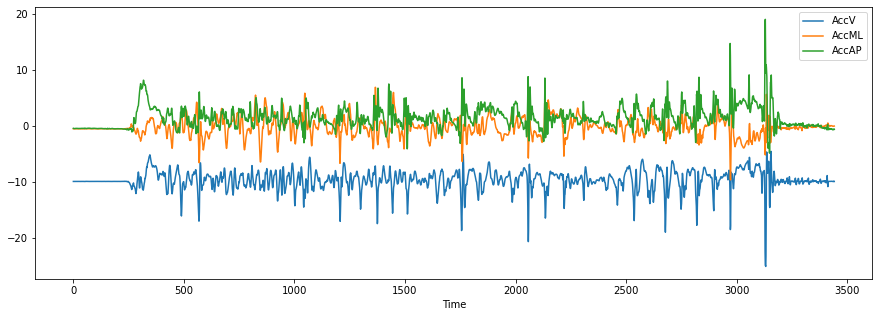

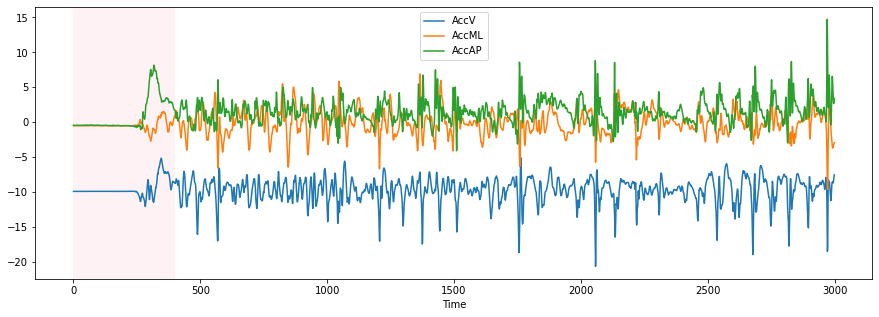

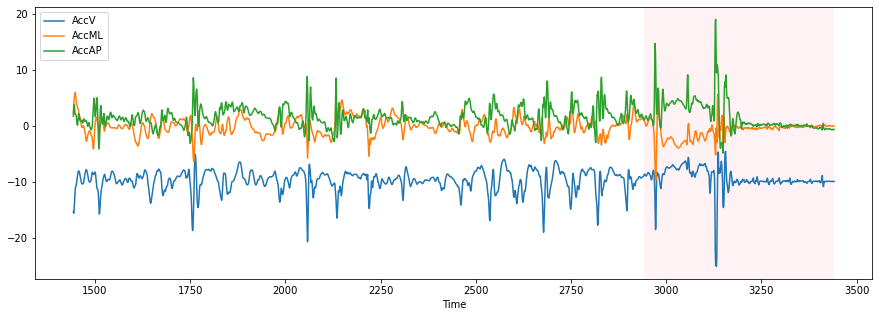

In [7]:
#Sprawdź początek i koniec nagrania
cols = ['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn' , 'Walking']
df = pd.read_csv(train[15], index_col='Time', usecols=cols)

def highlight(indices, ax):
    i=0
    while i<len(indices):
        ax.axvspan(indices[i]-0.5, indices[i]+0.5, facecolor='pink', edgecolor='none', alpha=.2)
        i+=1
ax = df[['AccV', 'AccML', 'AccAP']].plot(figsize=(15, 5))     
        
ax2 = df[['AccV', 'AccML', 'AccAP']].iloc[0:3000].plot(figsize=(15, 5))
highlight(df.iloc[0:400].index, ax2)

ax3 = df[['AccV', 'AccML', 'AccAP']].iloc[-2000:-1].plot(figsize=(15, 5))
highlight(df.iloc[-500:-1].index, ax3)


### Histogramy i korelacja metadanych

<AxesSubplot:>

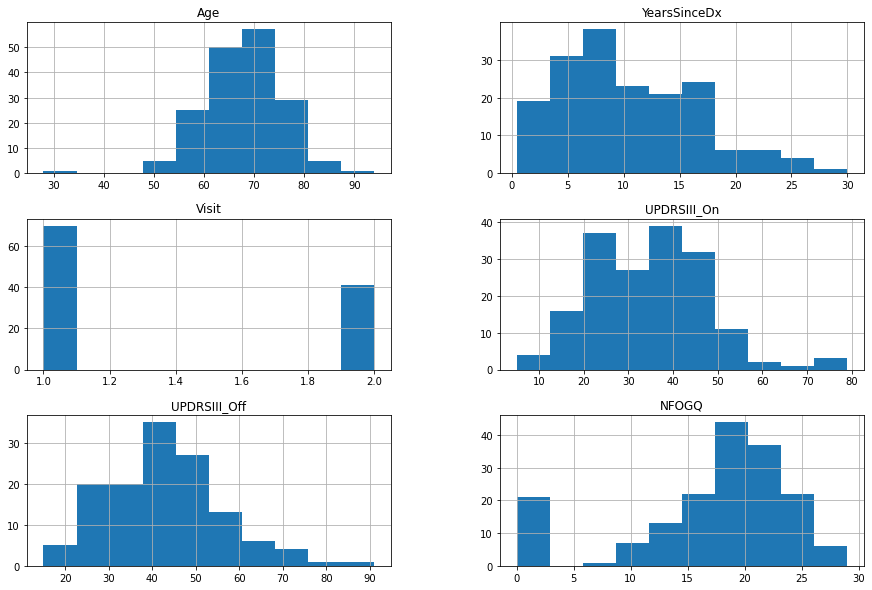

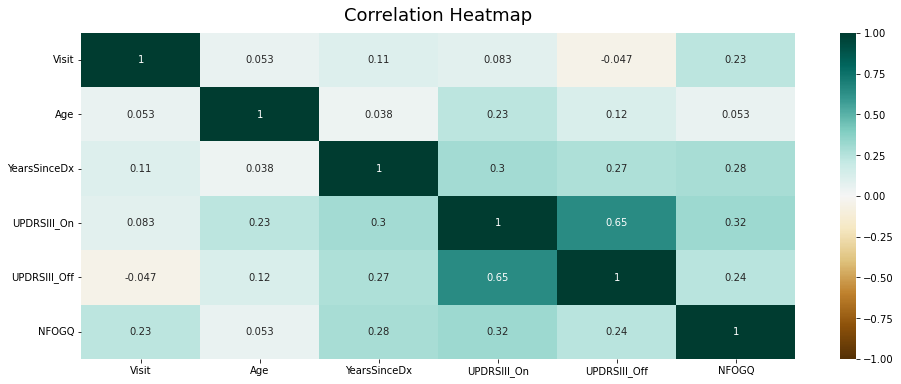

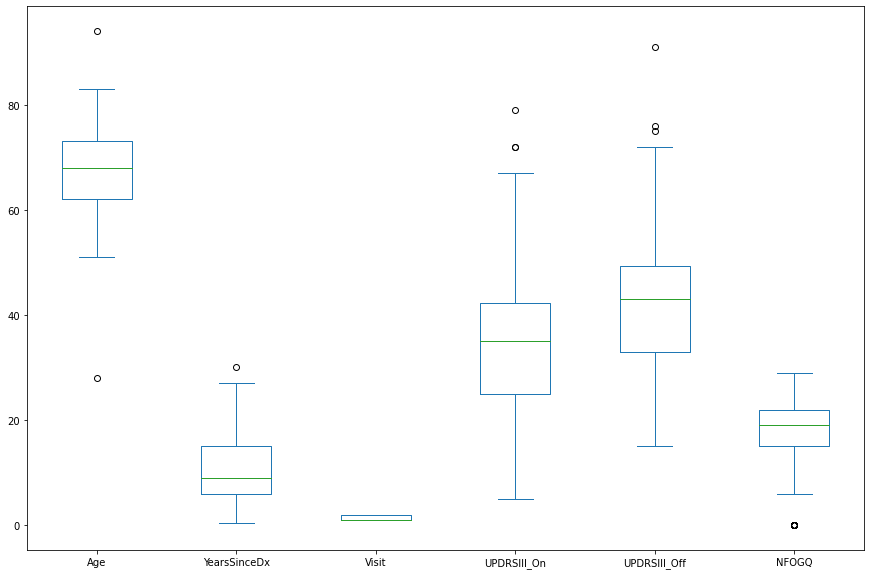

In [115]:
#histogramy wykresów i korelacje dla badanych
subjects[['Age', 'YearsSinceDx', 'Sex', 'Visit', 'UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']].hist(figsize=(15, 10))

plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(subjects.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12);

subjects[['Age', 'YearsSinceDx', 'Sex', 'Visit', 'UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']].plot.box(figsize=(15, 10))

### Inżynieria cech

In [116]:
seed = 100
cluster_size = 8

In [117]:
#zakoduj wartości kategoryczne jako liczby dla płci
subjects['Sex'] = subjects['Sex'].factorize()[0]
subjects = subjects.fillna(0).groupby('Subject').median()
subjects['s_group'] = cluster.KMeans(n_clusters = cluster_size, random_state = seed).fit_predict(subjects[subjects.columns[1:]])
#zamiana nazw kolumn
new_names = {'Visit':'s_visit','Age':'s_age','YearsSinceDx':'s_years','UPDRSIII_On':'s_on','UPDRSIII_Off':'s_off','NFOGQ':'s_NFOGQ', 'Sex': 's_sex'}
subjects = subjects.rename(columns = new_names)
subjects

,s_visit,s_age,s_sex,s_years,s_on,s_off,s_NFOGQ,s_group
Subject,,,,,,,,
00f674,1.5,63.0,0.0,27.0,37.0,39.5,25.0,5
02bc69,0.0,69.0,0.0,4.0,21.0,0.0,22.0,7
040587,1.5,75.0,0.0,26.0,49.5,72.0,22.5,6
056372,2.0,69.0,0.0,13.0,44.0,50.0,22.0,4
07285e,0.0,58.0,0.0,1.0,18.0,26.0,10.0,0
...,...,...,...,...,...,...,...,...
f686f0,0.0,61.0,0.0,7.0,44.0,0.0,24.0,7
f80507,1.0,57.0,0.0,2.0,12.0,0.0,0.0,2
fa8764,0.0,60.0,1.0,7.0,30.0,0.0,19.0,7


In [118]:
#dodaj odrębną kolumnę dla każdego typu zadania (predefiniowane zadania wykonywane przez pacjentów podczas sesji)
tasksBase['Duration'] = tasksBase['End'] - tasksBase['Begin']
tasks = pd.pivot_table(tasksBase, values=['Duration'], index=['Id'], columns=['Task'], aggfunc='sum', fill_value=0)
tasks.columns = [c[1] for c in tasks.columns]
tasks = tasks.reset_index()
tasks['t_group'] = cluster.KMeans(n_clusters = cluster_size, random_state = seed).fit_predict(tasks[tasks.columns[1:]])
tasks

,Id,4MW,4MW-C,Hotspot1,Hotspot1-C,Hotspot2,Hotspot2-C,MB1,MB10,MB11,MB12,MB13,MB2a,MB2b,MB3-L,MB3-R,MB4,MB5,MB6,MB6-L,MB6-R,MB7,MB8,MB9,Rest1,Rest2,TUG-C,TUG-DT,TUG-ST,Turning-C,Turning-DT,Turning-ST,t_group
0,02ab235146,16.520,16.680,16.760,16.240,53.920,64.600,13.960,17.960,17.400,8.600,7.937,4.84,5.080,6.059,21.800,1.880,3.520,0.0,2.080,1.520,30.600,12.840,30.800,180.48,60.32,38.440,47.920,36.240,21.920,46.400,23.320,5
1,02ea782681,11.618,11.796,11.525,11.692,8.329,9.032,3.469,6.624,6.230,5.379,9.040,0.00,7.715,22.851,22.584,6.553,8.919,0.0,5.126,9.444,31.769,11.849,30.650,0.00,0.00,18.343,19.932,20.130,18.042,21.588,18.698,1
2,06414383cf,24.860,41.584,25.885,0.000,38.642,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.000,44.832,33.867,0.000,83.837,124.299,0
3,092b4c1819,13.664,0.000,15.409,0.000,34.834,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.000,30.166,23.347,0.000,45.025,39.351,1
4,0a900ed8a2,11.720,11.840,10.600,10.720,43.171,41.160,1.760,21.040,10.560,4.520,9.186,7.40,4.640,47.960,40.840,1.400,1.840,0.0,1.440,1.440,30.720,31.040,30.520,180.88,60.32,18.083,25.000,19.920,18.699,18.200,16.880,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,f3a921edee,16.722,0.000,16.383,0.000,76.200,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.000,29.043,29.820,0.000,136.840,76.960,0
133,f40e8c6ebe,12.867,0.000,27.906,0.000,152.333,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.000,36.805,28.232,0.000,98.579,69.889,0
134,f8ddbdd98d,23.787,0.000,32.556,0.000,38.557,0.000,6.347,10.356,10.655,10.972,9.838,0.00,6.336,4.819,9.128,6.888,8.264,0.0,7.202,8.272,31.092,0.000,33.289,0.00,0.00,0.000,44.132,54.993,0.000,100.433,72.152,0
135,f9efef91fb,16.351,17.552,16.155,15.166,67.059,51.715,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.00,0.00,23.483,23.541,22.137,36.898,38.632,30.831,1


In [119]:
# połącz dane pacjentów z metadanymi
metadata_w_subjects = full_metadata.merge(subjects, how='left', on='Subject').copy()
features = metadata_w_subjects.columns

In [120]:
metadata_w_subjects['Medication'] = metadata_w_subjects['Medication'].factorize()[0]

### Przygotowanie danych, wyznaczenie parametrów statystycznych dla szeregu czasowego, szerokość okna = 5000

#### Metoda przesuwanego okna
<img src="../img/sliding-window.png">

In [121]:
basic_feats = MultipleFeatureDescriptors(
    functions=seglearn_feature_dict_wrapper(base_features()),
    series_names=['AccV', 'AccML', 'AccAP'],
    windows=[5000],
    strides=[5000],
)

emg_feats = emg_features()
del emg_feats['simple square integral'] # is same as abs_energy (which is in base_features)

emg_feats = MultipleFeatureDescriptors(
    functions=seglearn_feature_dict_wrapper(emg_feats),
    series_names=['AccV', 'AccML', 'AccAP'],
    windows=[5000],
    strides=[5000],
)

fc = FeatureCollection([basic_feats, emg_feats])

print(fc)

AccAP: (
	win: 5000  : [
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__mean, ['mean'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__median, ['median'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__abs_energy, ['abs_energy'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__std, ['std'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__var, ['var'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__minimum, ['minimum'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__maximum, ['maximum'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__skew, ['skew'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([seglearn_wrapped]__kurt, ['kurt'], {})    stride: ['5000'],
		FeatureDescriptor - func: FuncWrapper([s

### ETL - extract, transform, load
Dane pochodzą z róznych źródeł i róznią sie formatem:
1. jednostka pomiaru czujników dla pierwszego zbioru (tdcsfog) jest w m/s2 (czyli 1 m/s2), a dla drugiego (defog) w jednostce przyspieszenia ziemskiego g=9.81 m/s2
1. częstotliwość pomiarów dla pierwszego zbioru (tdcsfog) wynosi 128 Hz, a dla drugiego (defog) wynosi 100 Hz
1. jest oznaczenie prawidlowosci pomiarów dokonane przez specjalistow, jezeli stosunek poprawnych wyników do wszystkich wyników w sesji jest zbyt niski, usuwamy pomijamy cała sesję

In [122]:
pd.set_option('display.max_columns', None)

pd.set_option('display.max_columns', None)

def reader(file):
    try:
        path_split = file.split('/')
        session = path_split[-1].split('.')[0]
        dataset = Path(file).parts[-2]
        cols = ['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn' , 'Walking']
        if dataset == 'notype':
             cols = ['Time', 'AccV', 'AccML', 'AccAP', 'Event', 'Valid']
        if dataset == 'defog':        
            cols = ['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn' , 'Walking', 'Valid']
        df = pd.read_csv(file, index_col='Time', usecols=cols)
        df['Id'] = session
        df['Module'] = dataset
        
        if dataset == 'defog':
            c = df['Valid'].value_counts()
            validRatio = c[True]/(c[True] + c[False])
            if validRatio < 25:
                df.truncate()
            del df['Valid']

        if dataset == 'notype':
            df['Walking'] = 0
            df['Turn'] =  df['Event']
            df['StartHesitation'] = 0
            del df['Valid']
            del df['Event']

        # this is done because the speeds are at different rates for the datasets
        if dataset == 'tdcsfog':
            df.AccV = df.AccV * 9.80665
            df.AccML = df.AccML * 9.80665
            df.AccAP = df.AccAP * 9.80665

        df['Time_frac']=(df.index/df.index.max()).values

        df = pd.merge(df, tasks[['Id','t_group']], how='left', on='Id').fillna(-1)
        
        if dataset == 'tdcsfog':
            factor = 128
        else:
            factor = 100

        rows = tasksBase[tasksBase['Id'] == session]

        for index,row in rows.iterrows():
            t = df.iloc[0]['t_group']
            df.loc[:].t_group = -1
            start = int(row['Begin'] * factor)
            end = int(row['End'] * factor)
            df.loc[start:end].t_group = t
        
        df = pd.merge(df, metadata_w_subjects[['Id','Subject', 'Visit','Test','Medication','s_group']], how='left', on='Id').fillna(-1) # 's_off', 's_on', 's_age', 

        df_feats = fc.calculate(df, return_df=True, include_final_window=True, approve_sparsity=True, window_idx="begin").astype(np.float32)
        df = df.merge(df_feats, how="left", left_index=True, right_index=True)
        
        
        if dataset == 'notype':
            df.drop(index=df.iloc[0:85000].index, inplace=True)
        
        df.fillna(method="ffill", inplace=True)

        return df
    except: pass
   
train = pd.concat([reader(f) for f in tqdm(train)]).fillna(0); 
cols = [c for c in train.columns if c not in ['Id','Subject','Module', 'Time', 'StartHesitation', 'Turn' , 'Walking', 'Valid', 'Task','Event']]
cols = [x for x in cols if str(x) != 'nan']
pcols = ['StartHesitation', 'Turn' , 'Walking']
scols = ['Id', 'StartHesitation', 'Turn' , 'Walking']
train=train.reset_index(drop=True)

train.head()

  0%|          | 0/75 [00:00<?, ?it/s]

,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Module,Time_frac,t_group,Subject,Visit,Test,Medication,s_group,AccAP__abs_energy__w=5000,AccAP__abs_sum__w=5000,AccAP__emg_var__w=5000,AccAP__kurt__w=5000,AccAP__maximum__w=5000,AccAP__mean__w=5000,AccAP__mean_abs__w=5000,AccAP__mean_crossings__w=5000,AccAP__median__w=5000,AccAP__minimum__w=5000,AccAP__mse__w=5000,AccAP__root_mean_square__w=5000,AccAP__skew__w=5000,AccAP__slope_sign_changes__w=5000,AccAP__std__w=5000,AccAP__var__w=5000,AccAP__waveform_length__w=5000,AccAP__willison_amplitude__w=5000,AccAP__zero_crossing__w=5000,AccML__abs_energy__w=5000,AccML__abs_sum__w=5000,AccML__emg_var__w=5000,AccML__kurt__w=5000,AccML__maximum__w=5000,AccML__mean__w=5000,AccML__mean_abs__w=5000,AccML__mean_crossings__w=5000,AccML__median__w=5000,AccML__minimum__w=5000,AccML__mse__w=5000,AccML__root_mean_square__w=5000,AccML__skew__w=5000,AccML__slope_sign_changes__w=5000,AccML__std__w=5000,AccML__var__w=5000,AccML__waveform_length__w=5000,AccML__willison_amplitude__w=5000,AccML__zero_crossing__w=5000,AccV__abs_energy__w=5000,AccV__abs_sum__w=5000,AccV__emg_var__w=5000,AccV__kurt__w=5000,AccV__maximum__w=5000,AccV__mean__w=5000,AccV__mean_abs__w=5000,AccV__mean_crossings__w=5000,AccV__median__w=5000,AccV__minimum__w=5000,AccV__mse__w=5000,AccV__root_mean_square__w=5000,AccV__skew__w=5000,AccV__slope_sign_changes__w=5000,AccV__std__w=5000,AccV__var__w=5000,AccV__waveform_length__w=5000,AccV__willison_amplitude__w=5000,AccV__zero_crossing__w=5000
0,-94.323661,0.012192,7.087577,0,0,0,1a302f432f,tdcsfog,0.000000,-1.0,4ca9b3,4,3.0,1,0,2883736.75,112078.890625,576.862732,0.724491,59.01857,22.41321,22.415777,2.0,24.25662,-4.652517,2883736.75,24.015566,-0.078589,1144.0,8.625276,74.395386,5234.368652,4999.0,4999.0,195428.828125,21550.105469,39.093582,2.624353,18.579874,-2.631873,4.310021,254.0,-2.158131,-27.821171,195428.828125,6.251861,-0.851608,932.0,5.670892,32.159012,3967.097168,4999.0,4999.0,42143752.0,458349.15625,8430.436523,7.357015,-72.197685,-91.66983,91.66983,0.0,-91.63166,-144.623169,42143752.0,91.808228,-0.621081,1131.0,5.039067,25.392197,4119.027832,4999.0,4999.0
1,-94.327864,0.121131,6.997442,0,0,0,1a302f432f,tdcsfog,0.000035,-1.0,4ca9b3,4,3.0,1,0,2883736.75,112078.890625,576.862732,0.724491,59.01857,22.41321,22.415777,2.0,24.25662,-4.652517,2883736.75,24.015566,-0.078589,1144.0,8.625276,74.395386,5234.368652,4999.0,4999.0,195428.828125,21550.105469,39.093582,2.624353,18.579874,-2.631873,4.310021,254.0,-2.158131,-27.821171,195428.828125,6.251861,-0.851608,932.0,5.670892,32.159012,3967.097168,4999.0,4999.0,42143752.0,458349.15625,8430.436523,7.357015,-72.197685,-91.66983,91.66983,0.0,-91.63166,-144.623169,42143752.0,91.808228,-0.621081,1131.0,5.039067,25.392197,4119.027832,4999.0,4999.0
2,-94.107092,0.139428,7.130179,0,0,0,1a302f432f,tdcsfog,0.000071,-1.0,4ca9b3,4,3.0,1,0,2883736.75,112078.890625,576.862732,0.724491,59.01857,22.41321,22.415777,2.0,24.25662,-4.652517,2883736.75,24.015566,-0.078589,1144.0,8.625276,74.395386,5234.368652,4999.0,4999.0,195428.828125,21550.105469,39.093582,2.624353,18.579874,-2.631873,4.310021,254.0,-2.158131,-27.821171,195428.828125,6.251861,-0.851608,932.0,5.670892,32.159012,3967.097168,4999.0,4999.0,42143752.0,458349.15625,8430.436523,7.357015,-72.197685,-91.66983,91.66983,0.0,-91.63166,-144.623169,42143752.0,91.808228,-0.621081,1131.0,5.039067,25.392197,4119.027832,4999.0,4999.0
3,-94.174801,0.073081,7.062423,0,0,0,1a302f432f,tdcsfog,0.000106,-1.0,4ca9b3,4,3.0,1,0,2883736.75,112078.890625,576.862732,0.724491,59.01857,22.41321,22.415777,2.0,24.25662,-4.652517,2883736.75,24.015566,-0.078589,1144.0,8.625276,74.395386,5234.368652,4999.0,4999.0,195428.828125,21550.105469,39.093582,2.624353,18.579874,-2.631873,4.310021,254.0,-2.158131,-27.821171,195428.828125,6.251861,-0.851608,932.0,5.670892,32.159012,3967.097168,4999.0,4999.0,42143752.0,458349.15625,8430.436523,7.357015,-72.197685,-91.66983,91.66983,0.0,-91.63166,-144.623169,42143752.0,91.808228,-0.621081,1

### Trenowanie oraz walidacja k-rotna

In [123]:
best_params_ = {'colsample_bytree': 0.5282057895135501,
 'learning_rate': 0.22659963168004743,
 'max_depth': 8,
 'min_child_weight': 3.1233911067827616,
 'n_estimators': 291,
 'subsample': 0.9961057796456088,
 }

def custom_average_precision(y_true, y_pred):
    score = average_precision_score(y_true, y_pred)
    return 'average_precision', score, True

class LGBMMultiOutputRegressor(MultiOutputRegressor):
    def fit(self, X, y, eval_set=None, **fit_params):
        self.estimators_ = [clone(self.estimator) for _ in range(y.shape[1])]
        
        for i, estimator in enumerate(self.estimators_):
            if eval_set:
                fit_params['eval_set'] = [(eval_set[0], eval_set[1][:, i])]
            estimator.fit(X, y[:, i], **fit_params)
        
        return self

In [129]:
kfold = GroupKFold(5)
groups=kfold.split(train, groups=train.Subject)

regs = []
cvs = []

for _, (tr_idx, te_idx) in enumerate(tqdm(groups, total=5, desc="Folds")):
    
    tr_idx = pd.Series(tr_idx).sample(n=200000,random_state=42).values

    multioutput_regressor = LGBMMultiOutputRegressor(lgb.LGBMRegressor(**best_params_))

    x_train = train.loc[tr_idx, cols].to_numpy()
    y_train = train.loc[tr_idx, pcols].to_numpy()
    
    x_test = train.loc[te_idx, cols].to_numpy()
    y_test = train.loc[te_idx, pcols].to_numpy()

    multioutput_regressor.fit(
        x_train, y_train,
        eval_set=(x_test, y_test),
        eval_metric=custom_average_precision,
    )
    
    regs.append(multioutput_regressor)
    
    cv = metrics.average_precision_score(y_test, multioutput_regressor.predict(x_test).clip(0.0,1.0))
    
    cvs.append(cv)
    
print(cvs)

Folds:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13296
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 66
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Start training from score 0.009720
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

<img src="../img/model_hybrydowy.png">

### Wyniki 
#### Wykorzystana metryka ewaluacji modelu to średnia precyzja przewidywanych wyników ufności oddzielnie dla każdej z trzech klas epizodów
#### Model przedstawiony w tym przykładzie (uproszczony) uzyskał wynik 0,328.
Relatywnie niski wynik dla wszystkich 3 zdarzeń jest spowodowany kilkoma czynnikami, na które mozna zwrócić uwage przy projektowaniu kolejnych badań epizodów chodu choroby Parkinsona:
1. 1 z typów epizodów wystepuje dużo częściej od pozostałych (Walking). Brakuje danych w szczególności dla zdarzenia Start Hesitation.
2. Sposób detekcji epizodów zamrożenia chodu poprzez czujniki umieszczone na odcinku lędźwiowym pleców może być niewystarczajacy.
W praktyce odróznienie celowego bezruchu pacjenta od epizodu może dawać podobne rezultaty i być bardzo trudne do rozróżnienia.
Można spróbować zamocować czujniki również na kończynach lub badać dodatkowo inne czynniki, jak te zwiazane z tętnem, mimiką twarzy, itp. 